In [1]:
import os
import random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import kagglehub

**Download GTSRB dataset using kagglehub**

In [2]:
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")
print("Path to dataset files:", path)

100%|██████████| 612M/612M [00:05<00:00, 114MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1


**Dataset path**

In [3]:
train_path = os.path.join(path, "Train")
batch_size_val = 32
epochs_val = 15
imageDimensions = (64, 64, 3)
testRatio = 0.2
validationRatio = 0.2

**Load and preprocess dataset**

In [4]:
images = []
classNo = []
myList = os.listdir(train_path)
print("Total Classes Detected:", len(myList))
noOfClasses = len(myList)
print("Importing Classes...")

Total Classes Detected: 43
Importing Classes...


In [5]:
for count, classDir in enumerate(myList):
    classPath = os.path.join(train_path, classDir)
    for imageName in os.listdir(classPath):
        curImg = cv2.imread(os.path.join(classPath, imageName))
        curImg = cv2.resize(curImg, (imageDimensions[0], imageDimensions[1]))
        images.append(curImg)
        classNo.append(count)
    print(count, end=" ")

print("\nImport complete.")

0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 
Import complete.


In [6]:
images = np.array(images)
classNo = np.array(classNo)

**Split data**

In [7]:
X_train, X_test, y_train, y_test = train_test_split(images, classNo, test_size=testRatio)
X_train, X_validation, y_train, y_validation = train_test_split(X_train, y_train, test_size=validationRatio)

In [8]:
print("Data Shapes")
print("Train", X_train.shape, y_train.shape)
print("Validation", X_validation.shape, y_validation.shape)
print("Test", X_test.shape, y_test.shape)


Data Shapes
Train (25093, 64, 64, 3) (25093,)
Validation (6274, 64, 64, 3) (6274,)
Test (7842, 64, 64, 3) (7842,)


**Preprocessing functions**

In [9]:
def grayscale(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

def equalize(img):
    return cv2.equalizeHist(img)

def preprocessing(img):
    img = grayscale(img)
    img = equalize(img)
    img = img / 255
    return img

X_train = np.array(list(map(preprocessing, X_train)))
X_validation = np.array(list(map(preprocessing, X_validation)))
X_test = np.array(list(map(preprocessing, X_test)))

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2], 1)
X_validation = X_validation.reshape(X_validation.shape[0], X_validation.shape[1], X_validation.shape[2], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2], 1)

**Data augmentation**

In [10]:
dataGen = ImageDataGenerator(width_shift_range=0.1,
                             height_shift_range=0.1,
                             zoom_range=0.2,
                             shear_range=0.1,
                             rotation_range=10)
dataGen.fit(X_train)


**One-hot encoding**

In [11]:
y_train = to_categorical(y_train, noOfClasses)
y_validation = to_categorical(y_validation, noOfClasses)
y_test = to_categorical(y_test, noOfClasses)

**Model definition**

In [12]:
def build_model():
    model = Sequential()

    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(imageDimensions[0], imageDimensions[1], 1)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.2))

    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.3))

    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.4))

    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(noOfClasses, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model = build_model()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 62, 62, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 29, 29, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 12, 12, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         589,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 43)                  │           5,547 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 689,579 (2.63 MB)

 Trainable params: 688,875 (2.63 MB)

 Non-trainable params: 704 (2.75 KB)

None


**Train the model**

In [14]:
history = model.fit(
    dataGen.flow(X_train, y_train, batch_size=batch_size_val),
    steps_per_epoch=len(X_train) // batch_size_val,
    epochs=epochs_val,
    validation_data=(X_validation, y_validation),
    shuffle=True
)


Epoch 1/15


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


784/784 ━━━━━━━━━━━━━━━━━━━━ 302s 378ms/step - accuracy: 0.2756 - loss: 2.9878 - val_accuracy: 0.6653 - val_loss: 1.0796
Epoch 2/15
  1/784 ━━━━━━━━━━━━━━━━━━━━ 4:19 332ms/step - accuracy: 0.6875 - loss: 1.0573

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


784/784 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.6875 - loss: 1.0573 - val_accuracy: 0.6811 - val_loss: 1.0149
Epoch 3/15
784/784 ━━━━━━━━━━━━━━━━━━━━ 296s 377ms/step - accuracy: 0.6872 - loss: 1.0205 - val_accuracy: 0.9160 - val_loss: 0.2767
Epoch 4/15
784/784 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.8125 - loss: 0.6327 - val_accuracy: 0.9201 - val_loss: 0.2659
Epoch 5/15
784/784 ━━━━━━━━━━━━━━━━━━━━ 304s 372ms/step - accuracy: 0.8082 - loss: 0.6275 - val_accuracy: 0.9656 - val_loss: 0.1423
Epoch 6/15
784/784 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.8438 - loss: 0.3986 - val_accuracy: 0.9632 - val_loss: 0.1434
Epoch 7/15
784/784 ━━━━━━━━━━━━━━━━━━━━ 294s 375ms/step - accuracy: 0.8604 - loss: 0.4612 - val_accuracy: 0.9885 - val_loss: 0.0535
Epoch 8/15
784/784 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9062 - loss: 0.2208 - val_accuracy: 0.9876 - val_loss: 0.0548
Epoch 9/15
784/784 ━━━━━━━━━━━━━━━━━━━━ 293s 374ms/step - accuracy: 0.8847 - loss: 0.3788 - val

**Plot loss and accuracy**

Text(0.5, 0, 'Epoch')

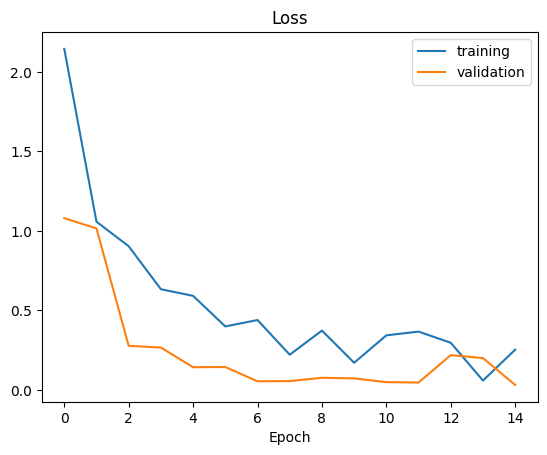

In [15]:
plt.figure(1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['training', 'validation'])
plt.title('Loss')
plt.xlabel('Epoch')

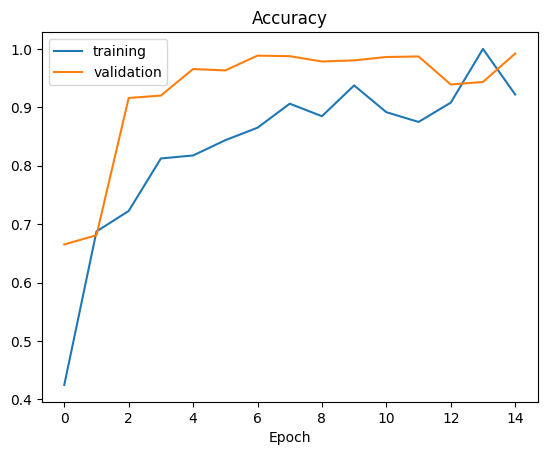

In [16]:
plt.figure(2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['training', 'validation'])
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.show()

**Evaluate the model**

In [17]:
score = model.evaluate(X_test, y_test, verbose=0)
print('Test Score:', score[0])
print('Test Accuracy:', score[1])


Test Score: 0.03457624465227127
Test Accuracy: 0.9904361367225647


In [18]:
model.save("gtsrb_traffic_sign_model.h5")

FileUpload(value={}, accept='image/*', description='Upload', multiple=True)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
 Traffic Sign Name: Speed Limit 20 km/h


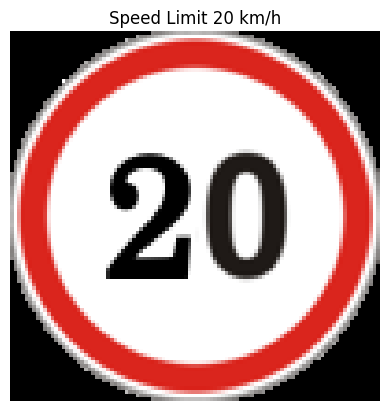

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
 Traffic Sign Name: Stop


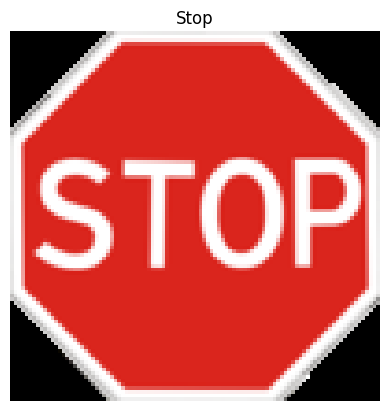

In [44]:
import os
import numpy as np
import cv2
from tensorflow.keras.models import load_model
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

# Load the trained model
model = load_model("gtsrb_traffic_sign_model.h5")
imageDimensions = (64, 64, 3)

# Class labels
class_labels = {
    0: "Speed Limit 20 km/h",
    1: "Speed Limit 30 km/h",
    2: "Speed Limit 50 km/h",
    3: "Speed Limit 60 km/h",
    4: "Speed Limit 70 km/h",
    5: "Speed Limit 80 km/h",
    6: "End of Speed Limit 80 km/h",
    7: "Speed Limit 100 km/h",
    8: "Speed Limit 120 km/h",
    9: "No Passing",
    10: "No Passing for Vehicles Over 3.5 Tons",
    11: "Right of Way at Intersection",
    12: "Priority Road",
    13: "Yield",
    14: "Stop",
    15: "No Vehicles",
    16: "Vehicles Over 3.5 Tons Prohibited",
    17: "No Entry",
    18: "General Caution",
    19: "Dangerous Curve to the Left",
    20: "Stop",
    21: "Double Curve",
    22: "Bumpy Road",
    23: "Slippery Road",
    24: "Road Narrows on the Right",
    25: "Road Work",
    26: "Traffic Signals",
    27: "Pedestrians",
    28: "Children Crossing",
    29: "Bicycles Crossing",
    30: "Speed Limit 20 km/h",
    31: "Wild Animals Crossing",
    32: "End of All Speed and Passing Limits",
    33: "Turn Right Ahead",
    34: "Turn Left Ahead",
    35: "Ahead Only",
    36: "Go Straight or Right",
    37: "Go Straight or Left",
    38: "Keep Right",
    39: "Keep Left",
    40: "Roundabout Mandatory",
    41: "End of No Passing",
    42: "End of No Passing by Vehicles Over 3.5 Tons"
}

def preprocessing(img):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.equalizeHist(img)
    img = img / 255
    return img

def select_and_predict_images():
    uploader = widgets.FileUpload(accept='image/*', multiple=True)
    display(uploader)

    def on_upload_change(change):
        for filename, fileinfo in uploader.value.items():
            file_bytes = np.frombuffer(fileinfo['content'], np.uint8)
            img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)

            if img is None:
                print(f"Image {filename} could not be loaded.")
                continue

            original_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (imageDimensions[0], imageDimensions[1]))
            img = preprocessing(img)
            img = img.reshape(1, imageDimensions[0], imageDimensions[1], 1)

            predictions = model.predict(img)
            class_index = np.argmax(predictions)

            print(f" Traffic Sign Name: {class_labels[class_index]}")
            plt.imshow(original_img)
            plt.title(f"{class_labels[class_index]}")
            plt.axis('off')
            plt.show()

    uploader.observe(on_upload_change, names='value')

# Run the function
select_and_predict_images()
